# CRSP v2 Daily Basic EDA

This notebook performs basic exploratory data analysis on `crsp_v2_2014_2024.csv` with emphasis on univariate analysis.

Scope:
- Data loading and quick schema checks
- Missing values and duplicate diagnostics
- Univariate analysis for categorical, numeric, and date fields
- Basic sanity checks for OHLC and returns
- Export of summary tables for downstream modeling


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
print("Libraries loaded.")

Libraries loaded.


In [2]:
# Config
DATA_PATH = Path("H:\\My Drive\\Project\\FA Project\\Data\\Raw Data\\crsp_v2_2014_2024.csv")
OUTPUT_DIR = Path("H:\\My Drive\\Project\\FA Project\\Data\\eda_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Set SAMPLE_N = None to use full data.
SAMPLE_N = 200000
RANDOM_SEED = 42

core_columns = [
    "permno", "permco", "ticker", "cusip", "issuernm", "siccd", "naics",
    "dlycaldt", "dlyclose", "dlyopen", "dlyhigh", "dlylow", "dlyprc",
    "dlyret", "dlyretx", "dlyvol", "shrout", "dlycap", "dlycumfacpr",
    "dlycumfacshr", "sprtrn", "vwretd", "ewretd", "securitytype",
    "sharetype", "usincflg", "shradrflg"
]

numeric_candidates = [
    "dlyclose", "dlyopen", "dlyhigh", "dlylow", "dlyprc", "dlyret", "dlyretx",
    "dlyvol", "shrout", "dlycap", "dlycumfacpr", "dlycumfacshr", "sprtrn",
    "vwretd", "ewretd"
]

categorical_candidates = ["securitytype", "sharetype", "usincflg", "shradrflg", "ticker"]

print(f"Data path: {DATA_PATH.resolve()}")
print(f"Output path: {OUTPUT_DIR.resolve()}")

Data path: H:\My Drive\Project\FA Project\Data\Raw Data\crsp_v2_2014_2024.csv
Output path: H:\My Drive\Project\FA Project\Data\eda_outputs


In [3]:
# Load data
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH, low_memory=False)

available_core_cols = [c for c in core_columns if c in df.columns]
missing_core_cols = [c for c in core_columns if c not in df.columns]

if "dlycaldt" in df.columns:
    df["dlycaldt"] = pd.to_datetime(df["dlycaldt"], errors="coerce")

for col in [c for c in numeric_candidates if c in df.columns]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# if SAMPLE_N is not None and SAMPLE_N < len(df):
#     df = df.sample(n=SAMPLE_N, random_state=RANDOM_SEED).sort_index().reset_index(drop=True)

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Available core columns: {len(available_core_cols)}")
if missing_core_cols:
    print("Missing expected core columns:", missing_core_cols)

df.head()

Rows: 495,987
Columns: 27
Available core columns: 27


,permno,permco,ticker,cusip,issuernm,siccd,naics,dlycaldt,dlyclose,dlyopen,dlyhigh,dlylow,dlyprc,dlyret,dlyretx,dlyvol,shrout,dlycap,dlycumfacpr,dlycumfacshr,sprtrn,vwretd,ewretd,securitytype,sharetype,usincflg,shradrflg
0,10104,8045,ORCL,68389X10,ORACLE CORP,7372,511210,2014-01-02,37.84,37.78,38.03,37.550,37.84,-0.010978,-0.010978,18163700.0,4497409,1.701820e+08,1.0,1.0,-0.008862,-0.008757,-0.004051,EQTY,NS,Y,N
1,10104,8045,ORCL,68389X10,ORACLE CORP,7372,511210,2014-01-03,37.62,37.65,37.86,37.560,37.62,-0.002643,-0.005814,11693900.0,4497409,1.691925e+08,1.0,1.0,-0.000333,0.000491,0.004096,EQTY,NS,Y,N
2,10104,8045,ORCL,68389X10,ORACLE CORP,7372,511210,2014-01-06,37.47,37.64,37.80,37.415,37.47,-0.003987,-0.003987,15330000.0,4497409,1.685179e+08,1.0,1.0,-0.002512,-0.003340,-0.001676,EQTY,NS,Y,N
3,10104,8045,ORCL,68389X10,ORACLE CORP,7372,511210,2014-01-07,37.85,37.66,37.93,37.500,37.85,0.010141,0.010141,16793300.0,4497409,1.702269e+08,1.0,1.0,0.006082,0.006090,0.006892,EQTY,NS,Y,N
4,10104,8045,ORCL,68389X10,ORACLE CORP,7372,511210,2014-01-08,37.72,37.79,37.91,37.560,37.72,-0.003435,-0.003435,16111600.0,4497409,1.696423e+08,1.0,1.0,-0.000212,0.000155,0.000835,EQTY,NS,Y,N


In [4]:
# Identifier governance: keep one primary identifier
IDENTIFIER_PRIMARY = "permco"
IDENTIFIER_CANDIDATES = ["permno", "permco", "ticker", "cusip"]

if IDENTIFIER_PRIMARY not in df.columns:
    raise KeyError(f"Primary identifier '{IDENTIFIER_PRIMARY}' not found in data")

df_model = df.copy()

existing_ids = [c for c in IDENTIFIER_CANDIDATES if c in df_model.columns]
secondary_ids = [c for c in existing_ids if c != IDENTIFIER_PRIMARY]

audit_rows = []
for sec in secondary_ids:
    pair = df_model[[IDENTIFIER_PRIMARY, sec]].dropna().drop_duplicates()
    sec_per_primary = pair.groupby(IDENTIFIER_PRIMARY)[sec].nunique()
    primary_per_sec = pair.groupby(sec)[IDENTIFIER_PRIMARY].nunique()
    audit_rows.append(
        {
            "primary_id": IDENTIFIER_PRIMARY,
            "secondary_id": sec,
            "rows_in_pair": int(len(pair)),
            "secondary_per_primary_max": int(sec_per_primary.max()) if not sec_per_primary.empty else 0,
            "secondary_per_primary_gt1": int((sec_per_primary > 1).sum()) if not sec_per_primary.empty else 0,
            "primary_per_secondary_max": int(primary_per_sec.max()) if not primary_per_sec.empty else 0,
            "primary_per_secondary_gt1": int((primary_per_sec > 1).sum()) if not primary_per_sec.empty else 0,
        }
    )

identifier_audit = pd.DataFrame(audit_rows)
identifier_audit.to_csv(OUTPUT_DIR / "identifier_governance_report.csv", index=False)

df_model = df_model.drop(columns=secondary_ids, errors="ignore")

print(f"Primary identifier kept: {IDENTIFIER_PRIMARY}")
print(f"Identifier columns dropped: {secondary_ids}")
if not identifier_audit.empty:
    display(identifier_audit)

Primary identifier kept: permco
Identifier columns dropped: ['permno', 'ticker', 'cusip']


,primary_id,secondary_id,rows_in_pair,secondary_per_primary_max,secondary_per_primary_gt1,primary_per_secondary_max,primary_per_secondary_gt1
0,permco,permno,188,2,2,1,0
1,permco,ticker,187,2,1,2,2
2,permco,cusip,198,4,10,1,0


In [5]:
# Remove single-value columns
single_value_cols = [c for c in df_model.columns if df_model[c].nunique(dropna=False) == 1]

single_value_report = pd.DataFrame(
    {
        "column": single_value_cols,
        "constant_value": [df_model[c].dropna().iloc[0] if df_model[c].notna().any() else np.nan for c in single_value_cols],
        "row_count": [len(df_model)] * len(single_value_cols),
    }
)

# Keep primary identifier regardless of constant check.
single_value_drop_cols = [c for c in single_value_cols if c != "permco"]
df_model = df_model.drop(columns=single_value_drop_cols, errors="ignore")

single_value_report.to_csv(OUTPUT_DIR / "single_value_columns_removed.csv", index=False)

print(f"Single-value columns detected: {len(single_value_cols)}")
print(f"Single-value columns dropped: {len(single_value_drop_cols)}")
if not single_value_report.empty:
    display(single_value_report)

Single-value columns detected: 4
Single-value columns dropped: 4


,column,constant_value,row_count
0,securitytype,EQTY,495987
1,sharetype,NS,495987
2,usincflg,Y,495987
3,shradrflg,N,495987


In [6]:
# Low-missingness numeric imputation (by company)
LOW_MISSING_PCT = 1.0

if "permco" not in df_model.columns:
    raise KeyError("permco must exist in df_model before imputation")

numeric_cols = [c for c in df_model.select_dtypes(include=[np.number]).columns if c != "permco"]
missing_pct = (df_model[numeric_cols].isna().mean() * 100).round(4) if numeric_cols else pd.Series(dtype=float)

impute_cols = [c for c in numeric_cols if 0 < missing_pct.loc[c] <= LOW_MISSING_PCT]
impute_rows = []

for col in impute_cols:
    before_missing = int(df_model[col].isna().sum())
    grouped_mean = df_model.groupby("permco")[col].transform("mean")
    global_mean = df_model[col].mean()

    df_model[col] = df_model[col].fillna(grouped_mean)
    fallback_mask = df_model[col].isna()
    fallback_count = int(fallback_mask.sum())
    if fallback_count > 0:
        df_model.loc[fallback_mask, col] = global_mean

    after_missing = int(df_model[col].isna().sum())
    impute_rows.append(
        {
            "column": col,
            "missing_before": before_missing,
            "missing_after": after_missing,
            "missing_pct_before": float(missing_pct.loc[col]),
            "method": "permco_mean_with_global_fallback",
            "global_fallback_count": fallback_count,
        }
    )

impute_report = pd.DataFrame(impute_rows).sort_values("missing_before", ascending=False)
impute_report.to_csv(OUTPUT_DIR / "imputation_report.csv", index=False)
df = df_model
print(f"Imputation threshold: <= {LOW_MISSING_PCT}% missing")
print(f"Columns imputed: {len(impute_cols)}")
if not impute_report.empty:
    display(impute_report)
else:
    print("No numeric columns met the low-missingness criterion.")


Imputation threshold: <= 1.0% missing
Columns imputed: 9


,column,missing_before,missing_after,missing_pct_before,method,global_fallback_count
0,dlyclose,277,0,0.0558,permco_mean_with_global_fallback,0
1,dlyopen,277,0,0.0558,permco_mean_with_global_fallback,0
2,dlyhigh,277,0,0.0558,permco_mean_with_global_fallback,0
3,dlylow,277,0,0.0558,permco_mean_with_global_fallback,0
5,dlyret,3,0,0.0006,permco_mean_with_global_fallback,0
6,dlyretx,3,0,0.0006,permco_mean_with_global_fallback,0
4,dlyprc,1,0,0.0002,permco_mean_with_global_fallback,0
7,dlyvol,1,0,0.0002,permco_mean_with_global_fallback,0
8,dlycap,1,0,0.0002,permco_mean_with_global_fallback,0


In [7]:
# Overview and quality diagnostics
schema_df = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(t) for t in df.dtypes],
    "missing_count": df.isna().sum().values,
    "missing_pct": (df.isna().mean() * 100).round(2).values,
    "n_unique": [df[c].nunique(dropna=True) for c in df.columns]
}).sort_values(["missing_pct", "n_unique"], ascending=[False, True])

display(schema_df.head(30))

full_dup_count = int(df.duplicated().sum())
if {"permno", "dlycaldt"}.issubset(df.columns):
    key_dup_count = int(df.duplicated(subset=["permno", "dlycaldt"]).sum())
else:
    key_dup_count = np.nan

print(f"Full-row duplicates: {full_dup_count:,}")
print(f"permno+dlycaldt duplicates: {key_dup_count}")

schema_df.to_csv(OUTPUT_DIR / "schema_missingness_summary.csv", index=False)

,column,dtype,missing_count,missing_pct,n_unique
16,dlycumfacshr,float64,0,0.0,16
15,dlycumfacpr,float64,0,0.0,44
2,siccd,int64,0,0.0,156
0,permco,int64,0,0.0,186
3,naics,int64,0,0.0,201
1,issuernm,str,0,0.0,204
17,sprtrn,float64,0,0.0,2640
18,vwretd,float64,0,0.0,2643
19,ewretd,float64,0,0.0,2644
4,dlycaldt,datetime64[us],0,0.0,2768


Full-row duplicates: 16
permno+dlycaldt duplicates: nan


In [8]:
# Categorical univariate analysis
existing_cats = [c for c in categorical_candidates if c in df.columns]
cat_freq_tables = {}

for col in existing_cats:
    top_n = 20 if col == "ticker" else 10
    freq = (
        df[col]
        .fillna("<NA>")
        .astype(str)
        .value_counts(dropna=False)
        .head(top_n)
        .rename_axis(col)
        .reset_index(name="count")
    )
    freq["pct"] = (freq["count"] / len(df) * 100).round(2)
    cat_freq_tables[col] = freq
    display(freq)

    plt.figure(figsize=(10, 4))
    sns.barplot(data=freq, x=col, y="count", color="#2A9D8F")
    plt.title(f"Top categories: {col}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

if cat_freq_tables:
    cat_export = pd.concat(
        [v.assign(variable=k) for k, v in cat_freq_tables.items()],
        ignore_index=True
    )
    cat_export.to_csv(OUTPUT_DIR / "categorical_univariate_summary.csv", index=False)
    print("Categorical summary exported.")

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_count,missing_pct
dlyclose,495987.0,1.601277e+02,2.812614e+02,2.100000,1.222000e+01,2.433000e+01,5.505000e+01,9.168000e+01,1.614000e+02,4.664170e+02,1.583994e+03,5.300340e+03,0,0.0
dlyopen,495987.0,1.601119e+02,2.812490e+02,2.200000,1.223000e+01,2.430300e+01,5.504000e+01,9.166000e+01,1.613900e+02,4.663870e+02,1.583123e+03,5.300000e+03,0,0.0
dlyhigh,495987.0,1.617596e+02,2.842795e+02,2.600000,1.240000e+01,2.461000e+01,5.558000e+01,9.256000e+01,1.629800e+02,4.713770e+02,1.598095e+03,5.337240e+03,0,0.0
dlylow,495987.0,1.584262e+02,2.781279e+02,1.930000,1.206000e+01,2.401000e+01,5.451000e+01,9.074000e+01,1.598100e+02,4.613170e+02,1.563174e+03,5.260000e+03,0,0.0
dlyprc,495987.0,1.601266e+02,2.812628e+02,2.100000,1.222000e+01,2.433000e+01,5.505000e+01,9.162000e+01,1.614200e+02,4.664170e+02,1.583994e+03,5.300340e+03,0,0.0
dlyret,495987.0,5.988199e-04,1.823258e-02,-0.538647,-4.926100e-02,-2.575970e-02,-7.398000e-03,7.570000e-04,8.801000e-03,2.591640e-02,4.967656e-02,6.464650e-01,0,0.0
dlyretx,495987.0,5.085910e-04,1.825539e-02,-0.538647,-4.943014e-02,-2.591400e-02,-7.513000e-03,6.800000e-04,8.735000e-03,2.585170e-02,4.960198e-02,6.464650e-01,0,0.0
dlyvol,495987.0,6.450495e+06,1.308823e+07,0.000000,1.708982e+05,4.565003e+05,1.292174e+06,2.667739e+06,6.254766e+06,2.457035e+07,6.026766e+07,6.575423e+08,0,0.0
shrout,495987.0,1.057452e+06,1.747422e+06,9064.000000,2.382700e+04,9.143800e+04,2.361450e+05,4.574510e+05,9.941270e+05,4.297435e+06,8.698115e+06,2.456884e+07,0,0.0
dlycap,495987.0,1.019672e+08,2.234873e+08,38249.400000,3.944628e+06,9.853115e+06,2.185662e+07,4.445715e+07,1.012778e+08,3.253285e+08,9.508571e+08,3.915300e+09,0,0.0


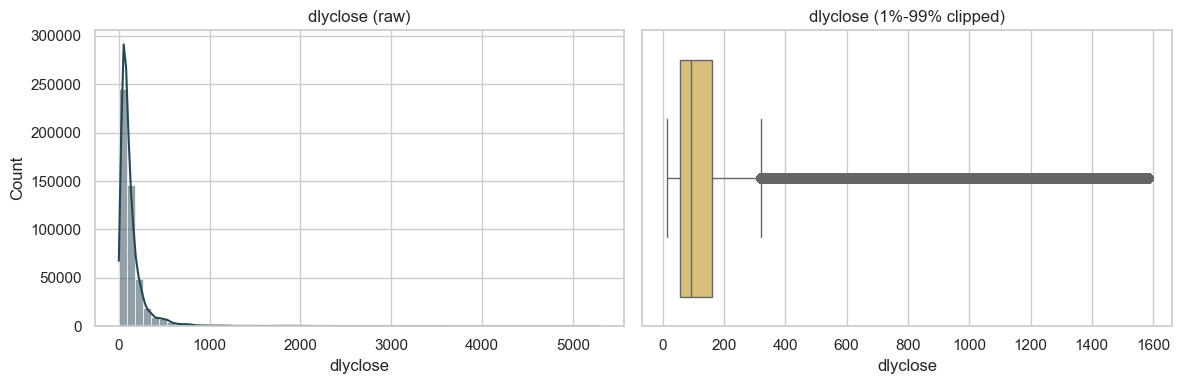

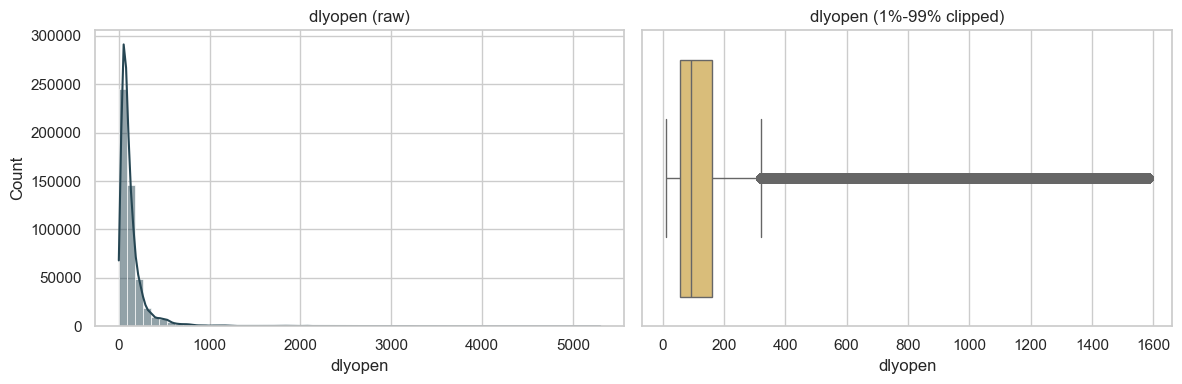

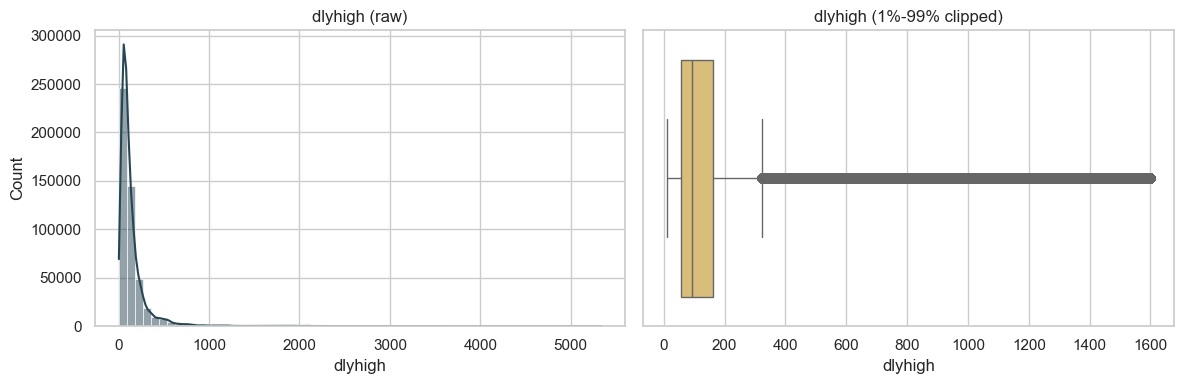

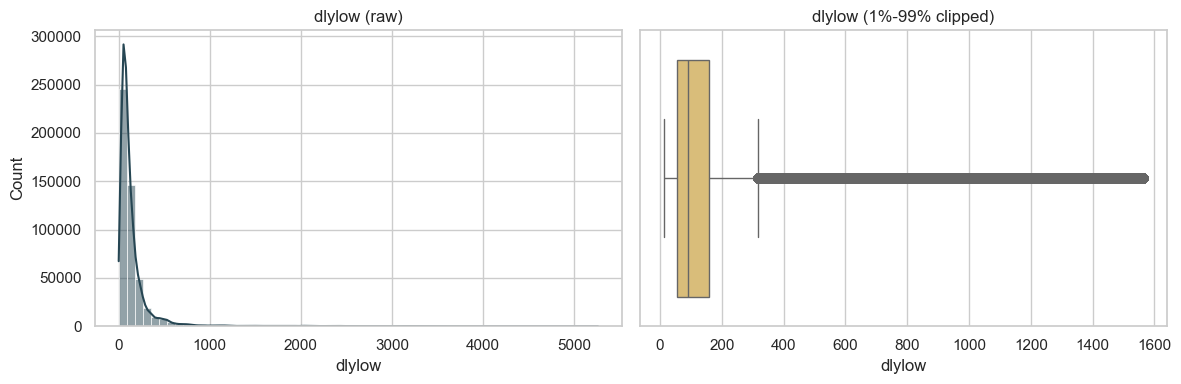

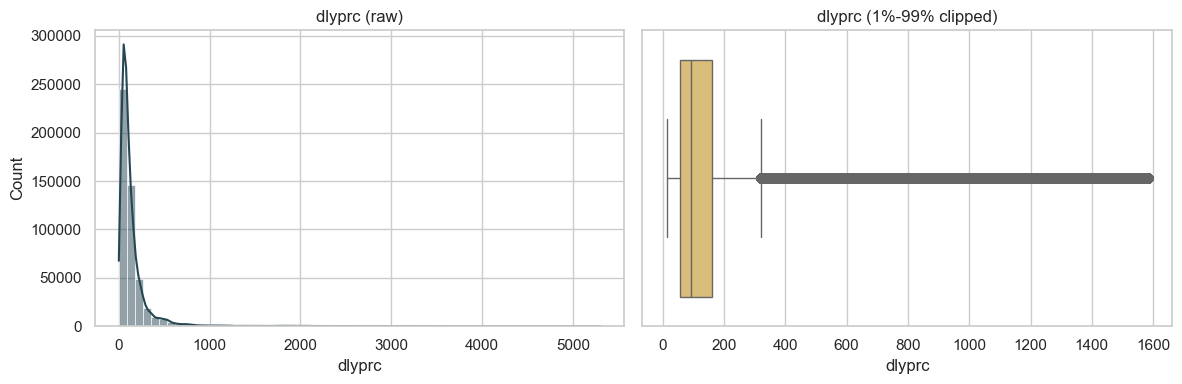

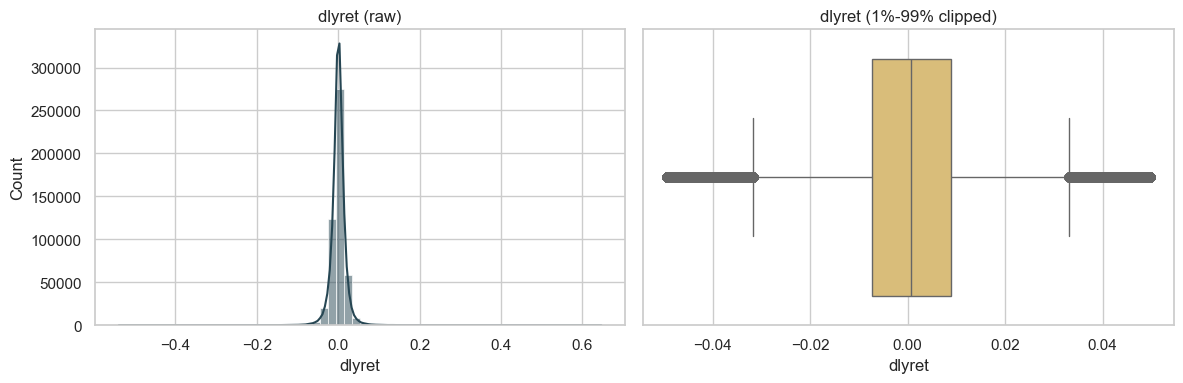

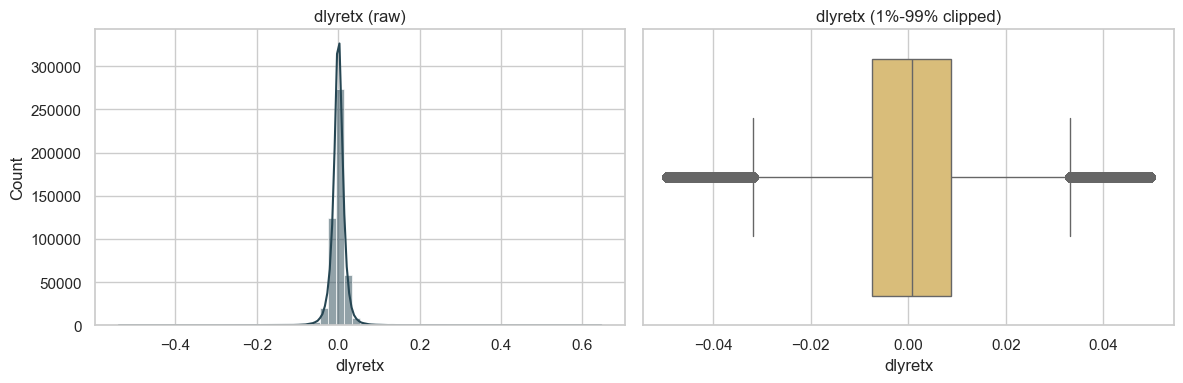

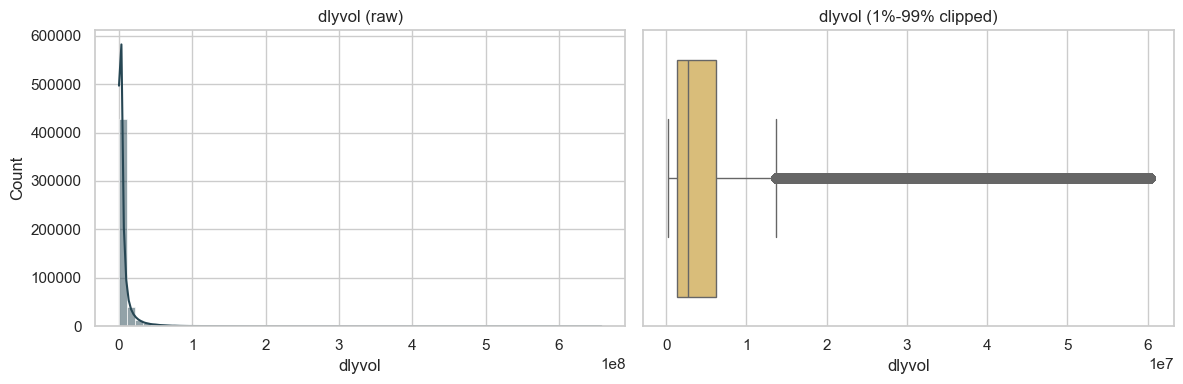

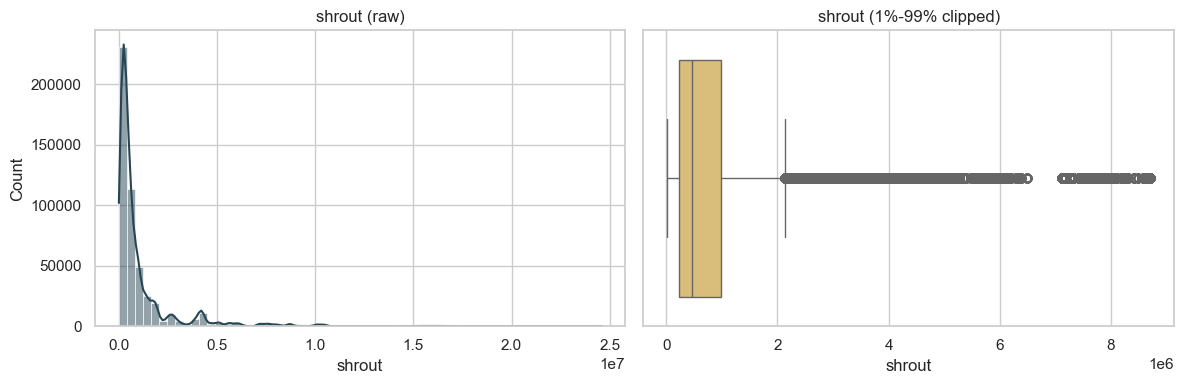

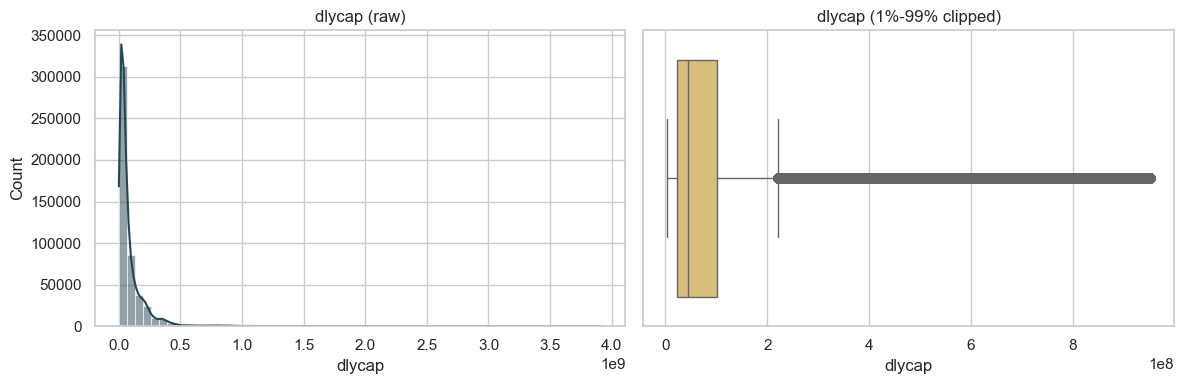

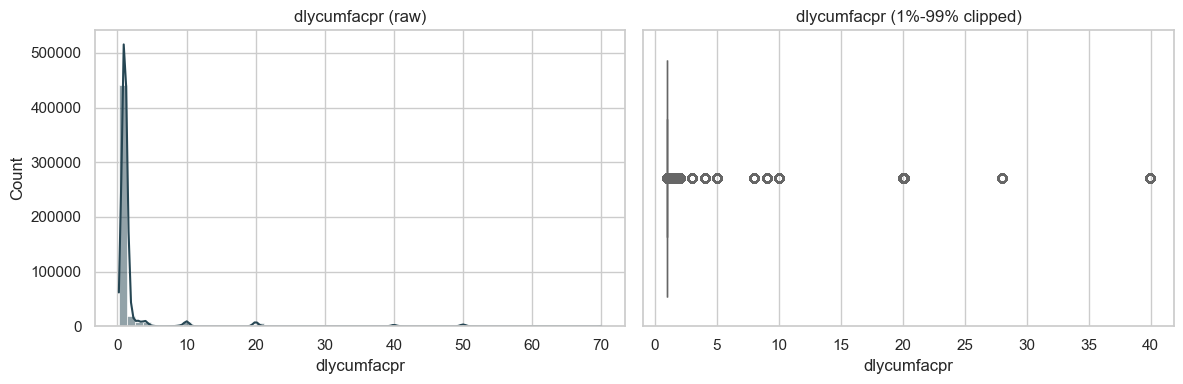

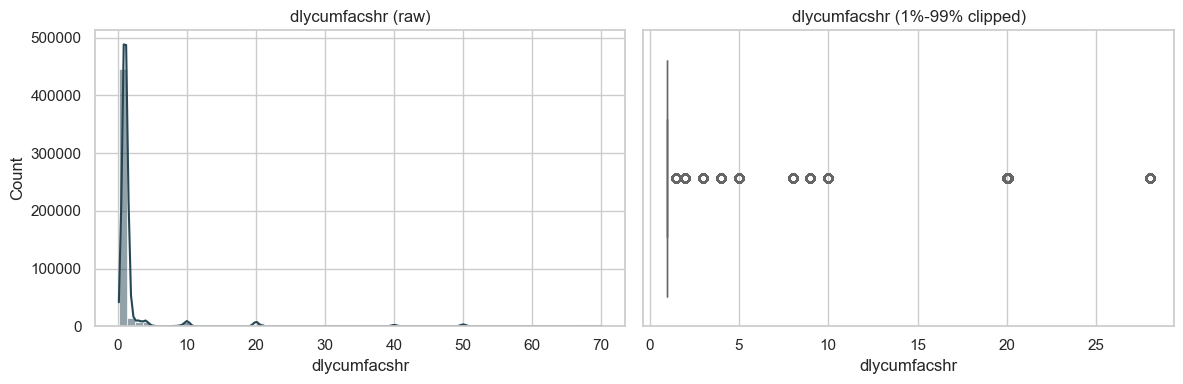

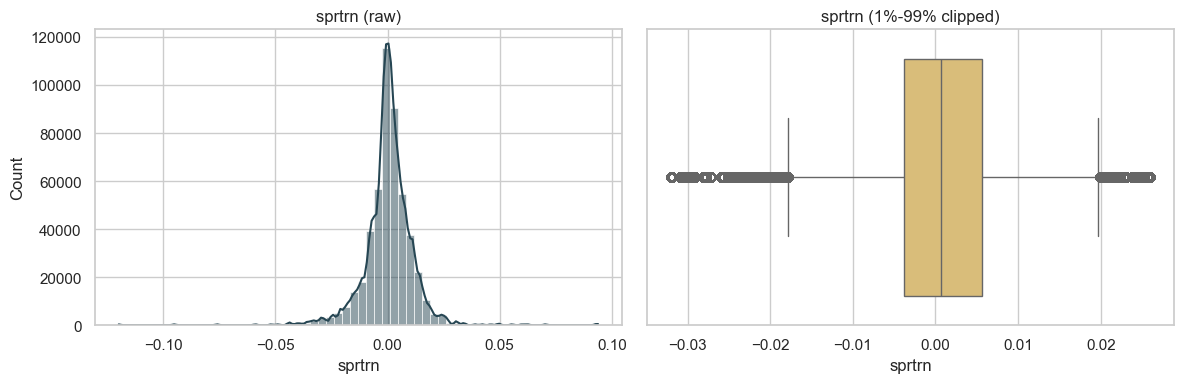

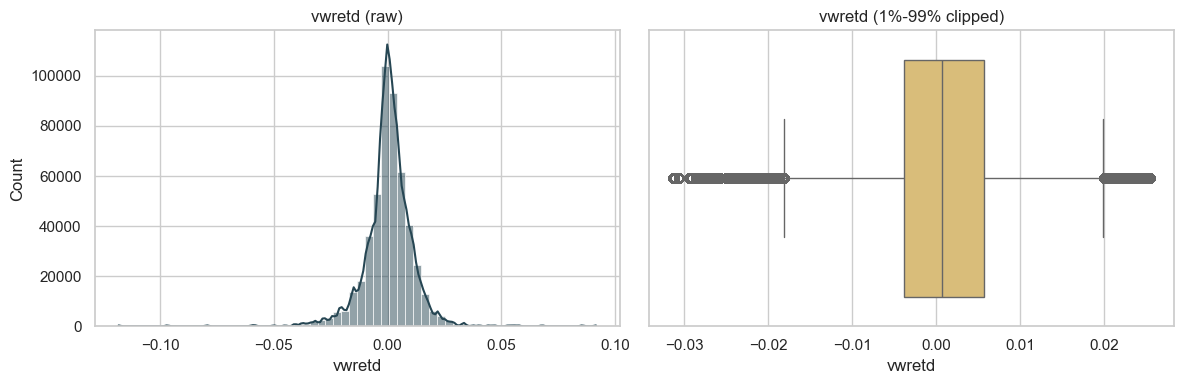

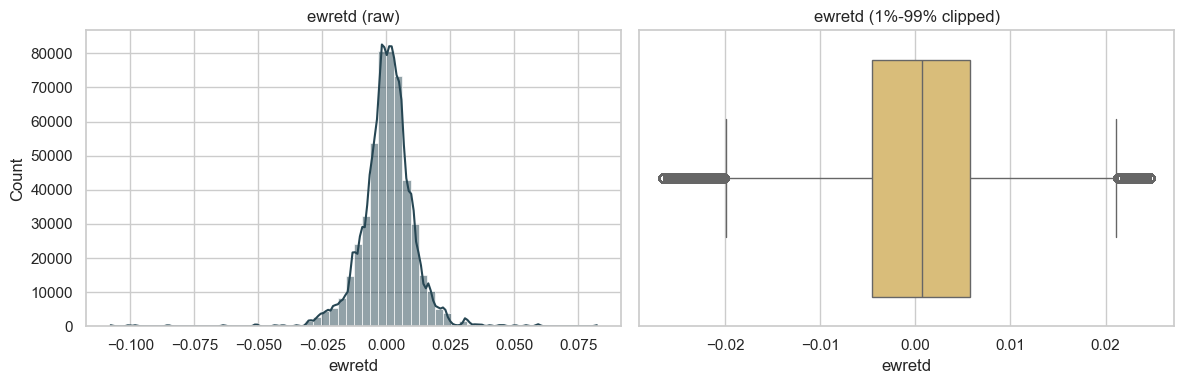

In [9]:
# Numeric univariate analysis
num_cols = [c for c in numeric_candidates if c in df.columns]

if num_cols:
    desc = df[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
    desc["missing_count"] = df[num_cols].isna().sum()
    desc["missing_pct"] = (df[num_cols].isna().mean() * 100).round(2)
    display(desc)
    desc.to_csv(OUTPUT_DIR / "numeric_univariate_summary.csv")

    for col in num_cols:
        series = df[col].dropna()
        if series.empty:
            continue

        p1, p99 = series.quantile([0.01, 0.99])
        clipped = series.clip(lower=p1, upper=p99)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        sns.histplot(series, bins=60, kde=True, ax=axes[0], color="#264653")
        axes[0].set_title(f"{col} (raw)")

        sns.boxplot(x=clipped, ax=axes[1], color="#E9C46A")
        axes[1].set_title(f"{col} (1%-99% clipped)")

        plt.tight_layout()
        plt.show()
else:
    print("No numeric columns from the candidate list were found.")

Date range: 2014-01-02 00:00:00 to 2024-12-31 00:00:00
Missing dlycaldt rows: 0


,year,row_count
0,2014,44786
1,2015,44499
2,2016,44535
3,2017,44428
4,2018,44862
5,2019,45360
6,2020,45731
7,2021,45443
8,2022,45326
9,2023,45194


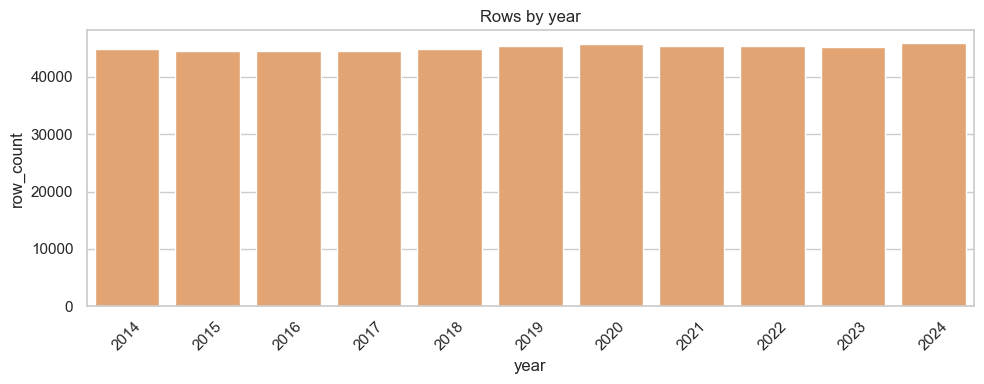

In [10]:
# Date univariate analysis
if "dlycaldt" in df.columns:
    min_dt = df["dlycaldt"].min()
    max_dt = df["dlycaldt"].max()
    missing_dt = int(df["dlycaldt"].isna().sum())

    print(f"Date range: {min_dt} to {max_dt}")
    print(f"Missing dlycaldt rows: {missing_dt:,}")

    by_year = (
        df.dropna(subset=["dlycaldt"])
        .assign(year=lambda x: x["dlycaldt"].dt.year)
        .groupby("year", as_index=False)
        .size()
        .rename(columns={"size": "row_count"})
    )
    display(by_year)

    plt.figure(figsize=(10, 4))
    sns.barplot(data=by_year, x="year", y="row_count", color="#F4A261")
    plt.title("Rows by year")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    by_year.to_csv(OUTPUT_DIR / "date_univariate_year_counts.csv", index=False)
else:
    print("dlycaldt not available.")

In [13]:
# Company-wise raw lag features (1, 5, 10, 21 trading days)
LAG_PERIODS = [1, 5, 10, 21]
LAG_COLUMNS = ["dlyopen", "dlyhigh", "dlylow", "dlyclose", "dlyvol", "dlycap"]

required_cols = {"permco", "dlycaldt", *LAG_COLUMNS}
missing_required = sorted(c for c in required_cols if c not in df_model.columns)
if missing_required:
    raise KeyError(f"Missing required columns for lag creation: {missing_required}")

lag_base = df_model.copy()
lag_base["dlycaldt"] = pd.to_datetime(lag_base["dlycaldt"], errors="coerce")

rows_before = len(lag_base)
lag_base = lag_base.dropna(subset=["dlycaldt"]).copy()
rows_after_drop_na_date = len(lag_base)

dup_mask = lag_base.duplicated(subset=["permco", "dlycaldt"], keep="first")
duplicates_dropped = int(dup_mask.sum())
if duplicates_dropped > 0:
    lag_base = lag_base.loc[~dup_mask].copy()

lag_base = lag_base.sort_values(["permco", "dlycaldt"]).reset_index(drop=True)

report_rows = []
created_lag_cols = []

for col in LAG_COLUMNS:
    grouped_series = lag_base.groupby("permco")[col]
    for lag in LAG_PERIODS:
        lag_col = f"lag{lag}_{col}"
        lag_base[lag_col] = grouped_series.shift(lag)
        created_lag_cols.append(lag_col)

        missing_count = int(lag_base[lag_col].isna().sum())
        report_rows.append(
            {
                "feature": col,
                "lag_period": lag,
                "rows": int(len(lag_base)),
                "missing_count": missing_count,
                "missing_pct": round(missing_count / len(lag_base) * 100, 4) if len(lag_base) else np.nan,
                "duplicates_dropped": duplicates_dropped,
                "rows_dropped_missing_date": int(rows_before - rows_after_drop_na_date),
            }
        )

lag_feature_report = pd.DataFrame(report_rows).sort_values(["lag_period", "feature"]).reset_index(drop=True)
lag_feature_report.to_csv(OUTPUT_DIR / "lag_feature_creation_report.csv", index=False)

# Push lagged frame back into modeling objects used by downstream cells.
df_model = lag_base
df = df_model

print(f"Rows before date-filter: {rows_before:,}")
print(f"Rows dropped due to missing dlycaldt: {rows_before - rows_after_drop_na_date:,}")
print(f"Rows dropped due to permco+dlycaldt duplicates: {duplicates_dropped:,}")
print(f"Rows after lag prep: {len(df_model):,}")
print(f"Lag columns created: {len(created_lag_cols)}")
print("Lag report saved to lag_feature_creation_report.csv")
display(lag_feature_report.head(12))

Rows before date-filter: 495,987
Rows dropped due to missing dlycaldt: 0
Rows dropped due to permco+dlycaldt duplicates: 5,489
Rows after lag prep: 490,498
Lag columns created: 24
Lag report saved to lag_feature_creation_report.csv


,feature,lag_period,rows,missing_count,missing_pct,duplicates_dropped,rows_dropped_missing_date
0,dlycap,1,490498,186,0.0379,5489,0
1,dlyclose,1,490498,186,0.0379,5489,0
2,dlyhigh,1,490498,186,0.0379,5489,0
3,dlylow,1,490498,186,0.0379,5489,0
4,dlyopen,1,490498,186,0.0379,5489,0
5,dlyvol,1,490498,186,0.0379,5489,0
6,dlycap,5,490498,930,0.1896,5489,0
7,dlyclose,5,490498,930,0.1896,5489,0
8,dlyhigh,5,490498,930,0.1896,5489,0
9,dlylow,5,490498,930,0.1896,5489,0


In [14]:
# Time-aware modeling split
if "dlycaldt" not in df_model.columns:
    raise KeyError("dlycaldt is required for time-aware split")

split_df = df_model.copy()
split_df["year"] = pd.to_datetime(split_df["dlycaldt"], errors="coerce").dt.year

split_df["split"] = np.select(
    [
        split_df["year"].between(2014, 2021, inclusive="both"),
        split_df["year"].between(2022, 2023, inclusive="both"),
        split_df["year"] == 2024,
    ],
    ["train", "validation", "test"],
    default="out_of_window",
)

split_summary = (
    split_df.groupby("split", dropna=False)
    .agg(
        rows=("permco", "size"),
        unique_permco=("permco", "nunique"),
        min_date=("dlycaldt", "min"),
        max_date=("dlycaldt", "max"),
    )
    .reset_index()
    .sort_values("split")
)

split_df.to_csv(OUTPUT_DIR / "time_aware_split_manifest.csv", index=False)
split_summary.to_csv(OUTPUT_DIR / "time_aware_split_summary.csv", index=False)

display(split_summary)

in_scope_rows = int(split_df[split_df["split"] != "out_of_window"].shape[0])
print(f"Rows in split window: {in_scope_rows:,} / {len(split_df):,}")

,split,rows,unique_permco,min_date,max_date
0,test,45318,180,2024-01-02,2024-12-31
1,train,355668,183,2014-01-02,2021-12-31
2,validation,89512,180,2022-01-03,2023-12-29


Rows in split window: 490,498 / 490,498


## Interpretation and Decision Log

### Pipeline Decisions
- Primary identifier retained for modeling: **permco**.
- Secondary identifiers dropped from the modeling frame after audit: permno, ticker, cusip.
- Single-value columns removed from modeling frame and logged to CSV.
- Low-missingness numeric columns imputed with **permco mean**, then global-mean fallback if required.
- Weekly smoothing generated using **W-FRI** aggregation at company level.
- Large daily jumps cross-checked against `dlycumfacpr` and `dlycumfacshr` events.
- Raw and adjusted fields retained for downstream model comparison.
- Time-aware split fixed as:
  - Train: 2014-2021
  - Validation: 2022-2023
  - Test: 2024

### Generated Artifacts
- `identifier_governance_report.csv`
- `single_value_columns_removed.csv`
- `imputation_report.csv`
- `weekly_company_ohlcv.csv`
- `corporate_action_alignment_events.csv`
- `adjusted_vs_raw_comparison_summary.csv`
- `time_aware_split_manifest.csv`
- `time_aware_split_summary.csv`

### Validation Notes (Fill After Run)
- Identifier collisions found (if any):
- Single-value columns dropped:
- Imputation columns and fallback counts:
- Weekly OHLC validity issues (if any):
- Share of large jumps aligned with factor events:
- Median absolute difference between `dlyretx` and manual adjusted-return proxy:
- Split row counts and company coverage by split:

### Risks / Follow-ups
- Using permco as the only identifier may merge multiple securities for the same company in edge cases.
- Mean imputation can dampen variance; validate model sensitivity with/without imputation.
- Adjustment-factor alignment should be manually reviewed for unaligned large-jump events.

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 490498 entries, 0 to 490497
Data columns (total 44 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   permco          490498 non-null  int64         
 1   issuernm        490498 non-null  str           
 2   siccd           490498 non-null  int64         
 3   naics           490498 non-null  int64         
 4   dlycaldt        490498 non-null  datetime64[us]
 5   dlyclose        490498 non-null  float64       
 6   dlyopen         490498 non-null  float64       
 7   dlyhigh         490498 non-null  float64       
 8   dlylow          490498 non-null  float64       
 9   dlyprc          490498 non-null  float64       
 10  dlyret          490498 non-null  float64       
 11  dlyretx         490498 non-null  float64       
 12  dlyvol          490498 non-null  float64       
 13  shrout          490498 non-null  int64         
 14  dlycap          490498 non-null  float64       

## LightGBM Baseline Training (Daily Panel)

This section trains a first baseline model using:
- target: next-day return (`dlyret` shifted by -1 within `permco`)
- split: existing time-aware split (`train` 2014-2021, `validation` 2022-2023, `test` 2024)
- features: engineered lags + core market/liquidity fields + encoded `permco`

In [16]:
import numpy as np
import pandas as pd
import lightgbm as lgb

# Build model frame from existing engineered dataset.
model_df = df_model.copy()
model_df["dlycaldt"] = pd.to_datetime(model_df["dlycaldt"], errors="coerce")
model_df = model_df.dropna(subset=["dlycaldt"]).copy()
model_df = model_df.sort_values(["permco", "dlycaldt"]).reset_index(drop=True)

# Ensure split exists (reuse prior split convention if needed).
if "split" not in model_df.columns:
    model_df["year"] = model_df["dlycaldt"].dt.year
    model_df["split"] = np.select(
        [
            model_df["year"].between(2014, 2021, inclusive="both"),
            model_df["year"].between(2022, 2023, inclusive="both"),
            model_df["year"] == 2024,
        ],
        ["train", "validation", "test"],
        default="out_of_window",
    )

# Target: next-day return inside each company panel.
target_col = "target_ret_t1"
model_df[target_col] = model_df.groupby("permco")["dlyret"].shift(-1)

# Candidate feature set = created lags + core predictors + encoded company id.
base_features = [
    "dlyopen", "dlyhigh", "dlylow", "dlyclose", "dlyvol", "dlycap", "shrout",
    "dlyret", "dlyretx", "sprtrn", "vwretd", "ewretd",
    "dlycumfacpr", "dlycumfacshr", "siccd", "naics", "permco"
]
lag_features = [c for c in model_df.columns if c.startswith("lag")]
feature_cols = [c for c in list(dict.fromkeys(base_features + lag_features)) if c in model_df.columns]

# Keep in-window rows and rows with non-missing target.
model_df = model_df[model_df["split"].isin(["train", "validation", "test"])].copy()
model_df = model_df.dropna(subset=[target_col]).copy()

# Use categorical dtype so LightGBM handles company identity natively.
model_df["permco"] = model_df["permco"].astype("category")

train_mask = model_df["split"] == "train"
val_mask = model_df["split"] == "validation"
test_mask = model_df["split"] == "test"

X_train = model_df.loc[train_mask, feature_cols]
y_train = model_df.loc[train_mask, target_col]
X_val = model_df.loc[val_mask, feature_cols]
y_val = model_df.loc[val_mask, target_col]
X_test = model_df.loc[test_mask, feature_cols]
y_test = model_df.loc[test_mask, target_col]

print("Feature count:", len(feature_cols))
print("Train/Val/Test shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Date coverage by split:")
print(model_df.groupby("split").agg(min_date=("dlycaldt", "min"), max_date=("dlycaldt", "max"), rows=("permco", "size")))

# Objects used in downstream cells.
lgb_model_df = model_df
lgb_feature_cols = feature_cols

Feature count: 41
Train/Val/Test shapes: (355663, 41) (89511, 41) (45138, 41)
Date coverage by split:
             min_date   max_date    rows
split                                   
test       2024-01-02 2024-12-30   45138
train      2014-01-02 2021-12-31  355663
validation 2022-01-03 2023-12-29   89511


In [17]:
# Native LightGBM baseline fit with early stopping on validation.
train_data = lgb.Dataset(
    X_train,
    label=y_train,
    categorical_feature=["permco"] if "permco" in X_train.columns else "auto",
    free_raw_data=False,
)
val_data = lgb.Dataset(
    X_val,
    label=y_val,
    categorical_feature=["permco"] if "permco" in X_val.columns else "auto",
    reference=train_data,
    free_raw_data=False,
)

params = {
    "objective": "regression",
    "metric": ["l1", "rmse"],
    "learning_rate": 0.03,
    "num_leaves": 64,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "seed": int(RANDOM_SEED),
    "verbosity": -1,
}

model = lgb.train(
    params=params,
    train_set=train_data,
    num_boost_round=2000,
    valid_sets=[val_data],
    valid_names=["validation"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=True),
        lgb.log_evaluation(period=100),
    ],
)

val_pred = model.predict(X_val, num_iteration=model.best_iteration)
test_pred = model.predict(X_test, num_iteration=model.best_iteration)

naive_val = np.zeros_like(y_val, dtype=float)
naive_test = np.zeros_like(y_test, dtype=float)

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def directional_acc(y_true, y_pred):
    return float((np.sign(y_true) == np.sign(y_pred)).mean())

metrics_df = pd.DataFrame(
    [
        {
            "split": "validation",
            "model": "lightgbm",
            "mae": mae(y_val.values, val_pred),
            "rmse": rmse(y_val.values, val_pred),
            "directional_acc": directional_acc(y_val.values, val_pred),
            "rows": int(len(y_val)),
        },
        {
            "split": "test",
            "model": "lightgbm",
            "mae": mae(y_test.values, test_pred),
            "rmse": rmse(y_test.values, test_pred),
            "directional_acc": directional_acc(y_test.values, test_pred),
            "rows": int(len(y_test)),
        },
        {
            "split": "validation",
            "model": "naive_zero",
            "mae": mae(y_val.values, naive_val),
            "rmse": rmse(y_val.values, naive_val),
            "directional_acc": directional_acc(y_val.values, naive_val),
            "rows": int(len(y_val)),
        },
        {
            "split": "test",
            "model": "naive_zero",
            "mae": mae(y_test.values, naive_test),
            "rmse": rmse(y_test.values, naive_test),
            "directional_acc": directional_acc(y_test.values, naive_test),
            "rows": int(len(y_test)),
        },
    ]
)

print("Best iteration:", model.best_iteration)
display(metrics_df)

Training until validation scores don't improve for 100 rounds
[100]	validation's l1: 0.0139601	validation's rmse: 0.0200714
Early stopping, best iteration is:
[2]	validation's l1: 0.0135127	validation's rmse: 0.0191679
Best iteration: 2


,split,model,mae,rmse,directional_acc,rows
0,validation,lightgbm,0.013513,0.019168,0.512484,89511
1,test,lightgbm,0.010880,0.016270,0.528845,45138
2,validation,naive_zero,0.013511,0.019156,0.003206,89511
3,test,naive_zero,0.010905,0.016281,0.003855,45138


In [18]:
# Diagnostics and exports.
feature_importance_df = (
    pd.DataFrame({
        "feature": lgb_feature_cols,
        "importance_gain": model.feature_importance(importance_type="gain"),
        "importance_split": model.feature_importance(importance_type="split"),
    })
    .sort_values("importance_gain", ascending=False)
    .reset_index(drop=True)
)

val_pred_df = lgb_model_df.loc[lgb_model_df["split"] == "validation", ["permco", "dlycaldt", target_col, "split"]].copy()
val_pred_df["prediction"] = val_pred

test_pred_df = lgb_model_df.loc[lgb_model_df["split"] == "test", ["permco", "dlycaldt", target_col, "split"]].copy()
test_pred_df["prediction"] = test_pred

predictions_df = pd.concat([val_pred_df, test_pred_df], ignore_index=True)

company_eval = (
    predictions_df.assign(
        abs_err=lambda x: (x[target_col] - x["prediction"]).abs(),
        dir_ok=lambda x: (np.sign(x[target_col]) == np.sign(x["prediction"])).astype(int),
    )
    .groupby(["split", "permco"], observed=True)
    .agg(mae=("abs_err", "mean"), directional_acc=("dir_ok", "mean"), rows=("abs_err", "size"))
    .reset_index()
)

# metrics_path = OUTPUT_DIR / "metrics_lightgbm_daily.csv"
# preds_path = OUTPUT_DIR / "predictions_lightgbm_daily.csv"
# fi_path = OUTPUT_DIR / "feature_importance_lightgbm_daily.csv"
# company_eval_path = OUTPUT_DIR / "company_metrics_lightgbm_daily.csv"

# metrics_df.to_csv(metrics_path, index=False)
# predictions_df.to_csv(preds_path, index=False)
# feature_importance_df.to_csv(fi_path, index=False)
# company_eval.to_csv(company_eval_path, index=False)

# print("Saved:")
# print("-", metrics_path)
# print("-", preds_path)
# print("-", fi_path)
# print("-", company_eval_path)

print("\nTop 20 features by gain:")
display(feature_importance_df.head(20))

print("\nPer-company MAE quantiles:")
display(company_eval.groupby("split")["mae"].quantile([0.1, 0.5, 0.9]).unstack())


Top 20 features by gain:


,feature,importance_gain,importance_split
0,sprtrn,10.221379,42
1,ewretd,4.764310,22
2,vwretd,3.393313,26
3,dlyret,1.669365,9
4,lag21_dlyvol,0.576068,6
5,lag1_dlyvol,0.421192,5
6,permco,0.160646,3
7,lag10_dlyvol,0.152245,3
8,dlyretx,0.100201,1
9,dlyopen,0.098693,1



Per-company MAE quantiles:


,0.1,0.5,0.9
split,,,
test,0.007732,0.010418,0.014110
validation,0.009735,0.012895,0.018464


## XGBoost, Random Forest, and CatBoost Comparison

This block fits three additional tree-based models on the same daily panel and prints validation/test metrics only.

In [19]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from catboost import CatBoostRegressor, Pool

# Reuse the already prepared modeling frame if it exists.
if "lgb_model_df" in globals() and "lgb_feature_cols" in globals() and "target_col" in globals():
    base_df = lgb_model_df.copy()
    feature_cols = list(lgb_feature_cols)
    target_name = target_col
else:
    base_df = df_model.copy()
    base_df["dlycaldt"] = pd.to_datetime(base_df["dlycaldt"], errors="coerce")
    base_df = base_df.dropna(subset=["dlycaldt"]).copy()
    base_df = base_df.sort_values(["permco", "dlycaldt"]).reset_index(drop=True)
    base_df["split"] = np.select(
        [
            base_df["dlycaldt"].dt.year.between(2014, 2021, inclusive="both"),
            base_df["dlycaldt"].dt.year.between(2022, 2023, inclusive="both"),
            base_df["dlycaldt"].dt.year == 2024,
        ],
        ["train", "validation", "test"],
        default="out_of_window",
    )
    base_df["target_ret_t1"] = base_df.groupby("permco")["dlyret"].shift(-1)
    base_df = base_df[base_df["split"].isin(["train", "validation", "test"])].dropna(subset=["target_ret_t1"]).copy()
    feature_cols = [
        c for c in base_df.columns
        if c not in {"target_ret_t1", "split", "dlycaldt"}
        and pd.api.types.is_numeric_dtype(base_df[c])
    ] + (["permco"] if "permco" in base_df.columns else [])
    target_name = "target_ret_t1"

# Build row-level masks.
train_mask = base_df["split"] == "train"
val_mask = base_df["split"] == "validation"
test_mask = base_df["split"] == "test"

# Shared target.
y_train = base_df.loc[train_mask, target_name].astype(float)
y_val = base_df.loc[val_mask, target_name].astype(float)
y_test = base_df.loc[test_mask, target_name].astype(float)

# Helper metrics.
def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def directional_acc(y_true, y_pred):
    return float((np.sign(np.asarray(y_true)) == np.sign(np.asarray(y_pred))).mean())

results = []

# 1) Random Forest
rf_features = [c for c in feature_cols if c != "permco"]
rf_train = base_df.loc[train_mask, rf_features].copy()
rf_val = base_df.loc[val_mask, rf_features].copy()
rf_test = base_df.loc[test_mask, rf_features].copy()
rf_train = rf_train.fillna(-999)
rf_val = rf_val.fillna(-999)
rf_test = rf_test.fillna(-999)

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=18,
    min_samples_leaf=50,
    max_samples=0.4,
    bootstrap=True,
    n_jobs=-1,
    random_state=RANDOM_SEED,
)
rf.fit(rf_train, y_train)
rf_val_pred = rf.predict(rf_val)
rf_test_pred = rf.predict(rf_test)
results.append({
    "model": "RandomForest",
    "split": "validation",
    "mae": mae(y_val, rf_val_pred),
    "rmse": rmse(y_val, rf_val_pred),
    "directional_acc": directional_acc(y_val, rf_val_pred),
})
results.append({
    "model": "RandomForest",
    "split": "test",
    "mae": mae(y_test, rf_test_pred),
    "rmse": rmse(y_test, rf_test_pred),
    "directional_acc": directional_acc(y_test, rf_test_pred),
})

# 2) XGBoost
xgb_features = [c for c in feature_cols if c != "permco"]
xgb_train = base_df.loc[train_mask, xgb_features].copy().fillna(-999)
xgb_val = base_df.loc[val_mask, xgb_features].copy().fillna(-999)
xgb_test = base_df.loc[test_mask, xgb_features].copy().fillna(-999)

xgb = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    tree_method="hist",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
xgb.fit(
    xgb_train,
    y_train,
    eval_set=[(xgb_val, y_val)],
    verbose=False,
)
xgb_val_pred = xgb.predict(xgb_val)
xgb_test_pred = xgb.predict(xgb_test)
results.append({
    "model": "XGBoost",
    "split": "validation",
    "mae": mae(y_val, xgb_val_pred),
    "rmse": rmse(y_val, xgb_val_pred),
    "directional_acc": directional_acc(y_val, xgb_val_pred),
})
results.append({
    "model": "XGBoost",
    "split": "test",
    "mae": mae(y_test, xgb_test_pred),
    "rmse": rmse(y_test, xgb_test_pred),
    "directional_acc": directional_acc(y_test, xgb_test_pred),
})

# 3) CatBoost
cat_df = base_df.copy()
cat_df["permco"] = cat_df["permco"].astype(str)
cat_features = [c for c in feature_cols if c in cat_df.columns]
cat_train = cat_df.loc[train_mask, cat_features].copy()
cat_val = cat_df.loc[val_mask, cat_features].copy()
cat_test = cat_df.loc[test_mask, cat_features].copy()
cat_feature_indices = [cat_train.columns.get_loc("permco")] if "permco" in cat_train.columns else []

cat_model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    random_seed=RANDOM_SEED,
    verbose=200,
    od_type="Iter",
    od_wait=100,
)
cat_model.fit(
    cat_train,
    y_train,
    eval_set=(cat_val, y_val),
    cat_features=cat_feature_indices,
    use_best_model=True,
)
cat_val_pred = cat_model.predict(cat_val)
cat_test_pred = cat_model.predict(cat_test)
results.append({
    "model": "CatBoost",
    "split": "validation",
    "mae": mae(y_val, cat_val_pred),
    "rmse": rmse(y_val, cat_val_pred),
    "directional_acc": directional_acc(y_val, cat_val_pred),
})
results.append({
    "model": "CatBoost",
    "split": "test",
    "mae": mae(y_test, cat_test_pred),
    "rmse": rmse(y_test, cat_test_pred),
    "directional_acc": directional_acc(y_test, cat_test_pred),
})

# Baseline for reference.
zero_val = np.zeros(len(y_val))
zero_test = np.zeros(len(y_test))
results.append({
    "model": "NaiveZero",
    "split": "validation",
    "mae": mae(y_val, zero_val),
    "rmse": rmse(y_val, zero_val),
    "directional_acc": directional_acc(y_val, zero_val),
})
results.append({
    "model": "NaiveZero",
    "split": "test",
    "mae": mae(y_test, zero_test),
    "rmse": rmse(y_test, zero_test),
    "directional_acc": directional_acc(y_test, zero_test),
})

metrics_df = pd.DataFrame(results).sort_values(["split", "mae", "rmse"]).reset_index(drop=True)
print("Metrics summary:")
display(metrics_df)

print("\nValidation ranking:")
display(metrics_df[metrics_df["split"] == "validation"].sort_values("mae").reset_index(drop=True))

print("\nTest ranking:")
display(metrics_df[metrics_df["split"] == "test"].sort_values("mae").reset_index(drop=True))

0:	learn: 0.0182279	test: 0.0191617	best: 0.0191617 (0)	total: 274ms	remaining: 6m 51s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.01916174847
bestIteration = 0

Shrink model to first 1 iterations.
Metrics summary:


,model,split,mae,rmse,directional_acc
0,CatBoost,test,0.010880,0.016268,0.528291
1,NaiveZero,test,0.010905,0.016281,0.003855
2,RandomForest,test,0.011060,0.016460,0.507045
3,XGBoost,test,0.011684,0.017257,0.506092
4,NaiveZero,validation,0.013511,0.019156,0.003206
5,CatBoost,validation,0.013514,0.019162,0.507334
6,RandomForest,validation,0.013963,0.019860,0.515467
7,XGBoost,validation,0.014562,0.020770,0.492152



Validation ranking:


,model,split,mae,rmse,directional_acc
0,NaiveZero,validation,0.013511,0.019156,0.003206
1,CatBoost,validation,0.013514,0.019162,0.507334
2,RandomForest,validation,0.013963,0.019860,0.515467
3,XGBoost,validation,0.014562,0.020770,0.492152



Test ranking:


,model,split,mae,rmse,directional_acc
0,CatBoost,test,0.010880,0.016268,0.528291
1,NaiveZero,test,0.010905,0.016281,0.003855
2,RandomForest,test,0.011060,0.016460,0.507045
3,XGBoost,test,0.011684,0.017257,0.506092
